Rows after cleaning: 4022
Features used: ['ma_gap_20', 'ma_gap_10', 'vol_10', 'ret_2', 'ret_5', 'ret_1', 'ret_4', 'vol_20', 'ret_3']

=== Accuracy ===
Scratch: 0.4838
Library: 0.4825

=== Confusion Matrix ===
Scratch:
 [[  0 142  17]
 [  2 358  35]
 [  2 216  30]]
Library:
 [[  2 140  17]
 [  6 365  24]
 [  2 226  20]]

=== Precision / Recall / F1 (Macro) ===
Scratch: 0.2886178861788618 0.34243228528651154 0.27542754275427545
Library: 0.34239495264365755 0.33909147018463875 0.26714369608446337

=== Log Loss ===
Scratch: 1.0415
Library: 1.0390


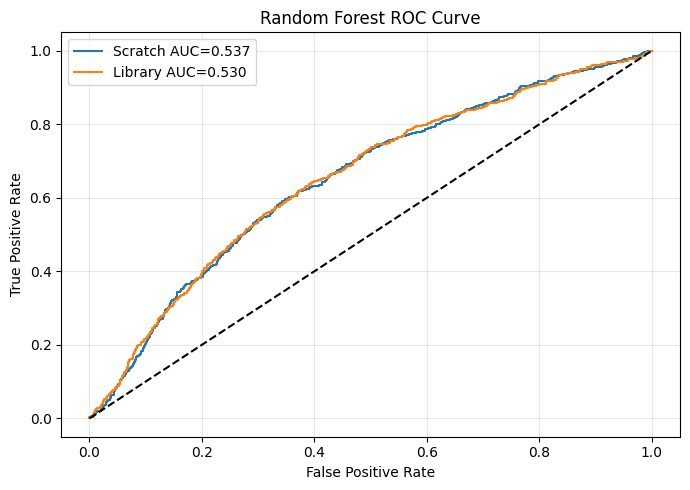

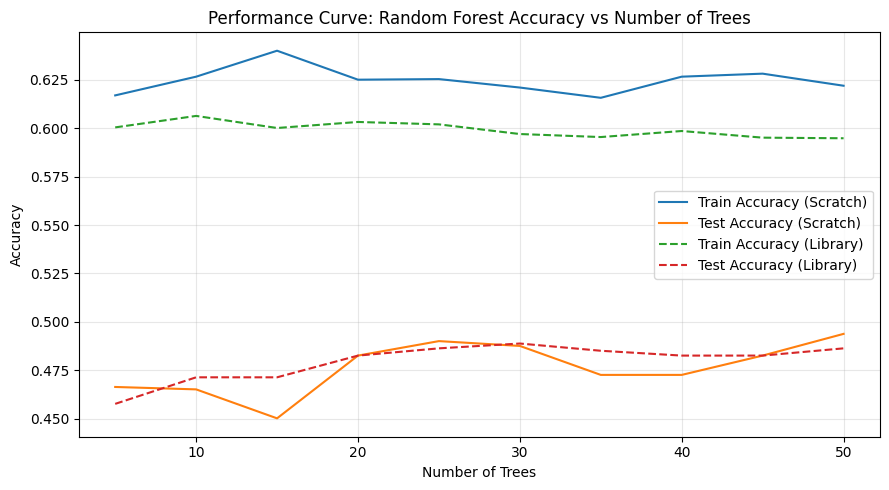

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    log_loss,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    mean_squared_error,
    r2_score,
    roc_curve,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

WINDOW_SIZE = 14
DATA_PATH = '../CLASSIFY-SnP_daily_update_AMZN_features_with_target.csv'
FEATURE_PATH = '../CLASSIFY-AMZN_methods_all_in_one.csv'
TARGET_COL = 'Target_Return_7d'

UP_THRESHOLD = 0.02
DOWN_THRESHOLD = -0.02

# --------------------------
# 1) Load data
# --------------------------
df = pd.read_csv(DATA_PATH)
feature_df = pd.read_csv(FEATURE_PATH)

requested_features = [
    'ma_gap_20', 'ma_gap_10', 'vol_10',
    'ret_2', 'ret_5',
    'ret_1',
    'ret_4',
    'vol_20',
    'ret_3'
]

allowed_features = feature_df['feature'].tolist() if 'feature' in feature_df.columns else []
feature_cols = [c for c in requested_features if c in allowed_features and c in df.columns]

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.sort_values('Date').reset_index(drop=True)

model_df = df[feature_cols + [TARGET_COL]].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print(f'Rows after cleaning: {len(model_df)}')
print('Features used:', feature_cols)

# --------------------------
# 2) Sliding Window
# --------------------------
def make_windows(x_values, y_values, window_size=14):
    Xw, yw = [], []
    for i in range(window_size, len(x_values)):
        Xw.append(x_values[i-window_size:i].reshape(-1))
        yw.append(y_values[i])
    return np.array(Xw), np.array(yw)

def map_target_3class(y_values, up_thr=0.03, down_thr=-0.03):
    y_cls = np.full_like(y_values, 1, dtype=np.int64)
    y_cls[y_values > up_thr] = 2
    y_cls[y_values < down_thr] = 0
    return y_cls

CLASS_LABELS = {0: 'Downtrend', 1: 'Sideway', 2: 'Uptrend'}

X_raw = model_df[feature_cols].values
y_raw_cont = model_df[TARGET_COL].values
y_raw = map_target_3class(y_raw_cont)

X_win, y_win = make_windows(X_raw, y_raw, WINDOW_SIZE)

split_idx = int(len(X_win) * 0.8)
X_train_raw, X_test_raw = X_win[:split_idx], X_win[split_idx:]
y_train, y_test = y_win[:split_idx], y_win[split_idx:]

# Standardize
x_mean = X_train_raw.mean(axis=0)
x_std = X_train_raw.std(axis=0)
x_std = np.where(x_std == 0, 1, x_std)

X_train = (X_train_raw - x_mean) / x_std
X_test = (X_test_raw - x_mean) / x_std

# ------------------------------------------
# 3) Random Forest from scratch (Bagging)
# ------------------------------------------
class RandomForestScratch:
    def __init__(self, n_estimators=20, max_depth=6):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples = X.shape[0]
        for _ in range(self.n_estimators):
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_sample = X[indices]
            y_sample = y[indices]
            tree = DecisionTreeClassifier(max_depth=self.max_depth)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict_proba(self, X):
        probs = np.zeros((X.shape[0], 3))
        for tree in self.trees:
            probs += tree.predict_proba(X)
        probs /= self.n_estimators
        return probs

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

# Train scratch RF
scratch_model = RandomForestScratch(n_estimators=20, max_depth=6)
scratch_model.fit(X_train, y_train)
y_prob_scratch = scratch_model.predict_proba(X_test)
y_pred_scratch = scratch_model.predict(X_test)

# ------------------------------------------
# 4) Library Random Forest
# ------------------------------------------
lib_model = RandomForestClassifier(
    n_estimators=20,
    max_depth=6,
    random_state=42
)
lib_model.fit(X_train, y_train)
y_prob_lib = lib_model.predict_proba(X_test)
y_pred_lib = lib_model.predict(X_test)

# ------------------------
# 5) Metrics
# ------------------------
classes = np.array([0,1,2])

print("\n=== Accuracy ===")
print(f"Scratch: {accuracy_score(y_test, y_pred_scratch):.4f}")
print(f"Library: {accuracy_score(y_test, y_pred_lib):.4f}")

print("\n=== Confusion Matrix ===")
print("Scratch:\n", confusion_matrix(y_test, y_pred_scratch, labels=classes))
print("Library:\n", confusion_matrix(y_test, y_pred_lib, labels=classes))

print("\n=== Precision / Recall / F1 (Macro) ===")
print("Scratch:",
      precision_score(y_test, y_pred_scratch, average='macro', zero_division=0),
      recall_score(y_test, y_pred_scratch, average='macro', zero_division=0),
      f1_score(y_test, y_pred_scratch, average='macro', zero_division=0))

print("Library:",
      precision_score(y_test, y_pred_lib, average='macro', zero_division=0),
      recall_score(y_test, y_pred_lib, average='macro', zero_division=0),
      f1_score(y_test, y_pred_lib, average='macro', zero_division=0))

print("\n=== Log Loss ===")
print(f"Scratch: {log_loss(y_test, y_prob_scratch, labels=classes):.4f}")
print(f"Library: {log_loss(y_test, y_prob_lib, labels=classes):.4f}")

# ------------------------
# 6) ROC Curve
# ------------------------
y_test_bin = label_binarize(y_test, classes=classes)

roc_auc_s = roc_auc_score(y_test_bin, y_prob_scratch, average='macro', multi_class='ovr')
roc_auc_l = roc_auc_score(y_test_bin, y_prob_lib, average='macro', multi_class='ovr')

fpr_s, tpr_s, _ = roc_curve(y_test_bin.ravel(), y_prob_scratch.ravel())
fpr_l, tpr_l, _ = roc_curve(y_test_bin.ravel(), y_prob_lib.ravel())

plt.figure(figsize=(7,5))
plt.plot(fpr_s, tpr_s, label=f"Scratch AUC={roc_auc_s:.3f}")
plt.plot(fpr_l, tpr_l, label=f"Library AUC={roc_auc_l:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------
# 7) Performance Curve: Accuracy vs n_estimators
# ------------------------
est_range = range(5, 51, 5)

train_acc_s = []
test_acc_s = []

train_acc_l = []
test_acc_l = []

for n in est_range:

    model_s = RandomForestScratch(n_estimators=n, max_depth=6)
    model_s.fit(X_train, y_train)
    train_acc_s.append(np.mean(model_s.predict(X_train) == y_train))
    test_acc_s.append(np.mean(model_s.predict(X_test) == y_test))

    model_l = RandomForestClassifier(
        n_estimators=n,
        max_depth=6,
        random_state=42
    )
    model_l.fit(X_train, y_train)
    train_acc_l.append(model_l.score(X_train, y_train))
    test_acc_l.append(model_l.score(X_test, y_test))

plt.figure(figsize=(9,5))
plt.plot(est_range, train_acc_s, label="Train Accuracy (Scratch)")
plt.plot(est_range, test_acc_s, label="Test Accuracy (Scratch)")
plt.plot(est_range, train_acc_l, linestyle="--", label="Train Accuracy (Library)")
plt.plot(est_range, test_acc_l, linestyle="--", label="Test Accuracy (Library)")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Performance Curve: Random Forest Accuracy vs Number of Trees")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()